In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Courses/2023 Fall CMPE 257/Colab/Linear Models/separable2vs8.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      985 non-null    int64  
 1   x1      985 non-null    float64
 2   x2      985 non-null    float64
 3   y       985 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 30.9 KB


<Axes: xlabel='x1', ylabel='x2'>

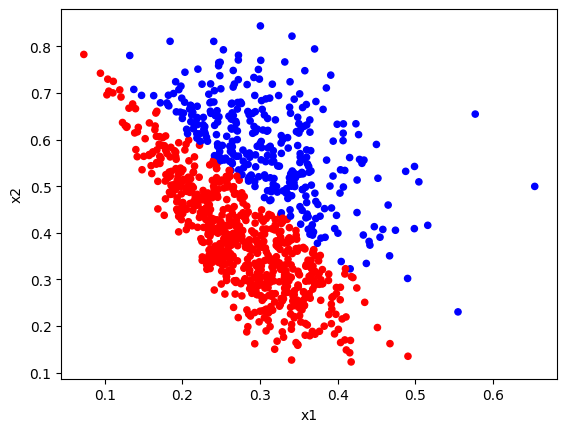

In [ ]:
col = df['y'].map({-1:'b', 1:'r'})
df.plot.scatter(x='x1', y='x2', c=col)

In [ ]:
df.head()

,x1,x2,y
0,0.458248,0.407339,-1
1,0.295803,0.436225,-1
2,0.304992,0.401522,-1
3,0.308186,0.236474,1
4,0.170111,0.590144,1


In [ ]:
X = np.array(df[['x1', 'x2']])
y = np.array(df[['y']])

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


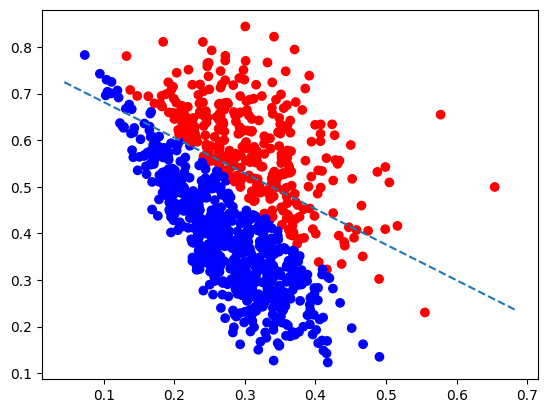

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X,y)
colors=[]
for y_col in y:
  if y_col == 1:
      colors.append('b')
  else:
      colors.append('r')
plt.scatter(X[:,0], X[:,1], color=colors)

intercept = -lr.intercept_[0]/lr.coef_[0,1]
slope = -lr.coef_[0,0]/lr.coef_[0,1]

axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', label = "x_2="+str(slope)+"x_1+"+str(intercept) )


In [ ]:
y_pred = lr.predict(X)
from sklearn import metrics
metrics.confusion_matrix(y, y_pred)

array([[255,  81],
       [ 14, 635]])

In [ ]:
metrics.accuracy_score(y, y_pred)

0.9035532994923858

In [ ]:
metrics.precision_score(y, y_pred)

0.8868715083798883

In [ ]:
metrics.f1_score(y, y_pred)

0.9304029304029304